In [1]:

from collections import defaultdict
import itertools
import nltk
from nltk import ngrams
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize
import numpy as np
import pandas as pd
import pickle
import re
import torch
import time
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from typing import List, Union, Optional
from torch.utils.data import DataLoader, Dataset

from dap_job_quality import config, PROJECT_DIR, logging, BUCKET_NAME
from dap_job_quality.getters.afs_data import get_eyp_ads, get_sim_occ_ads, get_jq_sentences
from dap_job_quality.getters.models import sentence_classifier_pca, sentence_classifier_lr
from dap_job_quality.getters.data_getters import save_to_s3
from dap_job_quality.getters.keywords import get_keywords

# Load BERT model and tokenizer
sent_model = SentenceTransformer('all-MiniLM-L6-v2')

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

model = sentence_classifier_lr()
pca = sentence_classifier_pca()

MAX_LENGTH = 81 # 99th percentile of token length of sentences
SAMPLE_SIZE = 'all'
SIMILARITY_THRESHOLD = 0

/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2024-06-19 15:42:38,859 - botocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2024-06-19 15:42:39,016 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2024-06-19 15:42:39,254 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device: cpu


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rosie.oxbury/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rosie.oxbury/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
def split_ngrams(text, length=6, n=4):
    if len(text.split()) > length:
        ngram_list = list(ngrams(text.split(), n))
    else:
        ngram_list = [text]
    return ngram_list

# List of weekdays and their abbreviations
weekdays = ["Monday", "Mon", "Tuesday", "Tues", "Wednesday", "Wed", "Thursday", "Thu", "Friday", "Fri", "Saturday", "Sat", "Sunday", "Sun"]

# Regular expression pattern to match weekdays as whole words
weekdays_pattern = '|'.join(map(re.escape, weekdays))

# Regular expression to split by the delimiters but not within numbers or weekdays
split_pattern = r'(?<!\d)[,;:\(\)](?!\d)|(?<!\d) - (?!\d)'

def split_text(text):
    # Split the text using the initial pattern
    initial_splits = re.split(split_pattern, text)
    
    # Further split to ensure no split happens between weekdays
    final_splits = []
    buffer = ""
    
    for segment in initial_splits:
        if re.search(rf'\b(?:{weekdays_pattern})\b', buffer) and re.search(rf'\b(?:{weekdays_pattern})\b', segment):
            buffer += ' - ' + segment
        else:
            if buffer:
                final_splits.append(buffer)
            buffer = segment
    
    if buffer:
        final_splits.append(buffer)
    
    return final_splits

def find_days(text):
    # List of weekdays and their abbreviations
    weekdays = ["Monday", "Mon", "Tuesday", "Tue", "Wednesday", "Wed", "Thursday", "Thu", "Friday", "Fri", "Saturday", "Sat", "Sunday", "Sun"]

    # Create a regular expression pattern that matches any of the weekdays or their abbreviations
    weekdays_pattern = r'\b(?:' + '|'.join(weekdays) + r')\b'
    # Use re.findall() to find all the matches of pattern in text
    return re.findall(weekdays_pattern, text)

In [3]:
split_text('£30,000 - £40,000')

['£30,000 - £40,000']

In [4]:
split_text('scales (AWR compliant)Free CPD')

['scales ', 'AWR compliant', 'Free CPD']

In [5]:
split_text('Monday - Friday')

['Monday - Friday']

In [6]:
split_text('Mon - Fri')

['Mon - Fri']

In [7]:
split_text('Tuesday - Friday')

['Tuesday - Friday']

In [8]:
split_text('insurance, life critical illness')

['insurance', ' life critical illness']

In [9]:
split_text('Mon - Fri; Tues - Fri')

['Mon - Fri -  Tues - Fri']

In [10]:
lookup = get_keywords()

2024-06-19 15:42:40,612 - aiobotocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [11]:
jq_sentences_df = get_jq_sentences()
jq_sentences_df.head()

,id,company_raw,job_title_raw,created,type,sector,parent_sector,knowledge_domain,occupation,min_annualised_salary,...,coordinates,clean_description,ruc11_code,ruc11,broad_ruc11,qualification_level,clean_job_title,matched_job_title,sentences,job_quality
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,"(51.54777527, -0.58521903)",Childcare | Permanent | Full or Part Time| 20 ...,3.0,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077
1,50087836,Additional Resources Ltd,Assistant Room Manager - Baby room,2023-03-24,Recruitment consultancy,Early Years Practitioner,Education,Education,Assistant Manager,21000.0,...,"(51.68258667, -0.31665)","Assistant Room Manager Location Radlett, (WD...",4.0,Urban with City and Town,Predominantly Urban,3,None,None,Staff pension scheme.,0.506460
2,50087836,Additional Resources Ltd,Assistant Room Manager - Baby room,2023-03-24,Recruitment consultancy,Early Years Practitioner,Education,Education,Assistant Manager,21000.0,...,"(51.68258667, -0.31665)","Assistant Room Manager Location Radlett, (WD...",4.0,Urban with City and Town,Predominantly Urban,3,None,None,Excellent in-house training and career progres...,0.382049
3,50087836,Additional Resources Ltd,Assistant Room Manager - Baby room,2023-03-24,Recruitment consultancy,Early Years Practitioner,Education,Education,Assistant Manager,21000.0,...,"(51.68258667, -0.31665)","Assistant Room Manager Location Radlett, (WD...",4.0,Urban with City and Town,Predominantly Urban,3,None,None,35 days holiday - 28 days inclusive of bank ho...,0.394663
4,50087836,Additional Resources Ltd,Assistant Room Manager - Baby room,2023-03-24,Recruitment consultancy,Early Years Practitioner,Education,Education,Assistant Manager,21000.0,...,"(51.68258667, -0.31665)","Assistant Room Manager Location Radlett, (WD...",4.0,Urban with City and Town,Predominantly Urban,3,None,None,Generous 80% childcare provision discount.,0.712310


In [12]:
jq_sentences_df['sentences_split'] = jq_sentences_df['sentences'].apply(split_text)
jq_sentences_df_long = jq_sentences_df.explode('sentences_split')
logging.info(f'Splitting sentences added {len(jq_sentences_df_long) - len(jq_sentences_df)} extra sentences. Total N sentences is now {len(jq_sentences_df_long)}')

2024-06-19 15:42:44,415 - root - INFO - Splitting sentences added 23654 extra sentences. Total N sentences is now 51426


In [13]:
jq_sentences_df_long['sentence_cleaned'] = jq_sentences_df_long['sentences_split'].str.replace(r'\d', 'X', regex=True)

# Get ngrams from JQ sentences

In [14]:
jq_sentences_df_long['ngrams'] = jq_sentences_df_long['sentence_cleaned'].apply(lambda x: split_ngrams(x, 6, 4))
jq_sentences_df_long = jq_sentences_df_long.explode('ngrams')
jq_sentences_df_long['ngrams'] = jq_sentences_df_long['ngrams'].apply(lambda x: ' '.join(x) if isinstance(x, tuple) else x)
jq_sentences_df_long.head(20)

,id,company_raw,job_title_raw,created,type,sector,parent_sector,knowledge_domain,occupation,min_annualised_salary,...,ruc11,broad_ruc11,qualification_level,clean_job_title,matched_job_title,sentences,job_quality,sentences_split,sentence_cleaned,ngrams
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,Find your perfect fit
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,your perfect fit with
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,perfect fit with our
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,fit with our impressive
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,with our impressive range
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,our impressive range of
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,impressive range of lifestyle
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,range of lifestyle and
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,Urban with Significant Rural (rural including ...,Urban with Significant Rural,None,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,of lifestyle and wellbeing
0

# Calculate cosine similarity of unique ngrams to target phrases

In [15]:
ngram_counts = pd.DataFrame(jq_sentences_df_long['ngrams'].value_counts()).reset_index()
ngram_counts

,ngrams,count
0,Access to CPD courses.,852
1,In-house Training and Development Team,790
2,and development for our,786
3,You will also receive,786
4,training and development for,785
...,...,...
31687,day per week XX,1
31688,options…X day per week,1
31689,Hours options…X day per,1
31690,Working Hours options…X day,1


In [16]:
unique_ngrams = ngram_counts['ngrams']

In [17]:
target_phrases = lookup['target_phrase'].tolist()

In [18]:
# Embed the target phrases
target_embeddings = sent_model.encode(target_phrases)
    
ngram_embeddings = sent_model.encode(unique_ngrams)
        
similarities = cosine_similarity(ngram_embeddings, target_embeddings)

Batches: 100%|██████████| 991/991 [00:58<00:00, 16.96it/s]


In [19]:
# Find the index of the highest cosine similarity for each n-gram
max_indices = np.argmax(similarities, axis=1)

# Retrieve the corresponding target phrases
most_similar_phrases = [target_phrases[index] for index in max_indices]

most_similar_similarities = [similarities[i, index] for i, index in enumerate(max_indices)]

most_similar_pairs = list(zip(unique_ngrams, most_similar_phrases, most_similar_similarities))

matches = pd.DataFrame(most_similar_pairs, columns=['ngrams', 'target_phrase', 'cosine_similarity'])

In [20]:
matches = pd.merge(matches, ngram_counts, on='ngrams', how='left')

<Axes: >

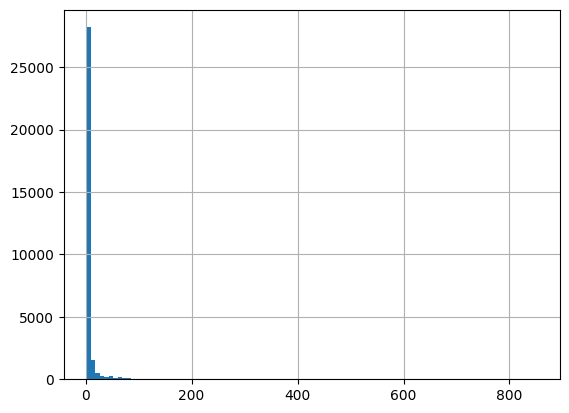

In [21]:
matches['count'].hist(bins=100)

In [22]:
matches['count'].describe()

count    31692.000000
mean         6.903099
std         28.805190
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        852.000000
Name: count, dtype: float64

In [23]:
jq_sentences_df_long = pd.merge(jq_sentences_df_long, matches, how='left', left_on='ngrams', right_on='ngrams')
jq_sentences_df_long.head()

,id,company_raw,job_title_raw,created,type,sector,parent_sector,knowledge_domain,occupation,min_annualised_salary,...,clean_job_title,matched_job_title,sentences,job_quality,sentences_split,sentence_cleaned,ngrams,target_phrase,cosine_similarity,count
0,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,Find your perfect fit,recommend a friend,0.285179,2
1,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,your perfect fit with,recommend a friend,0.265510,2
2,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,perfect fit with our,supportive team,0.315450,2
3,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,fit with our impressive,supportive team,0.308533,2
4,50086878,Nuffield Health,Nursery Nurse,2023-03-24,Direct employer,Early Years Practitioner,Education,Education,Nursery Nurse,20883.2,...,None,None,Find your perfect fit with our impressive rang...,0.330077,Find your perfect fit with our impressive rang...,Find your perfect fit with our impressive rang...,with our impressive range,performance bonus,0.255619,2


In [24]:
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')

In [25]:
today

'2024-06-19'

In [26]:
save_to_s3(BUCKET_NAME, jq_sentences_df_long, f'job_quality/early_years/jq_sentences/jq_sentences_2023_matched_{today}.parquet')
save_to_s3(BUCKET_NAME, matches, f'job_quality/early_years/jq_sentences/unique_ngrams_2023_matched_{today}.parquet')

2024-06-19 15:44:21,049 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/jq_sentences/jq_sentences_2023_matched_2024-06-19.parquet ...
2024-06-19 15:44:21,875 - dap_job_quality - INFO - Saved to s3://open-jobs-lake + job_quality/early_years/jq_sentences/unique_ngrams_2023_matched_2024-06-19.parquet ...


In [27]:
matches.to_csv('ngrams_new.csv')